## Анализ и прогнозирование временных рядов методами искусственного интеллекта

In [2]:
from google.colab import drive
import os

drive.mount('/content/drive')
practice_dir_path = '/content/drive/MyDrive/2025-Murzin-TimeSeriesCourse-main/practice/07 Imputation and Forecast'
os.chdir(practice_dir_path)

Mounted at /content/drive


In [3]:
!pwd

/content/drive/MyDrive/2025-Murzin-TimeSeriesCourse-main/practice/07 Imputation and Forecast


### **Практическая работа 7. Востановление пропусков и прогноз значений временного ряда.**


#### **7.1 Аналитечкие методы востановления временного ряда**

##### *Краткое описание*

В данном пункте практической работы вам предстоит познакомиться с базовыми, аналитическими методами восстановления временных рядов.
Для выполнения данного пункта из каждой группы методов, представленных в ***табл. 7.1*** вам необходимо выбрать по одному методу восстановления ряда. При работе с первой группой, вам необходимо самостоятельно реализовать выбранный метод.  

**Табл. 7.1** - Группы аналитических методов восстановления.
№|Название группы|Модели и методы|
--|----|----|
1|Заполнение существующими значениями ряда|Средним, медианной, Hot-Deck|
2|Заполнение на основе близки значений|[Интерполяция](https://scikit-learn.org/stable/auto_examples/linear_model/plot_polynomial_interpolation.html),  [KNNi](https://scikit-learn.org/stable/modules/generated/sklearn.impute.KNNImputer.html)|
3|На основе матричных разложений|[CD-Rec](#Fixme:Дат ссылку), [SVD](https://pypi.org/project/fancyimpute/)|

##### 7.1.1 Загрузка и подготовка данных

In [19]:
#from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [20]:
path_data = f'{practice_dir_path}/datasets/madrid.txt'
#path_data = Path('Dataset')/'madrid.txt'
madrid = np.loadtxt(path_data)[:,0]
print(madrid.shape)

(25000,)


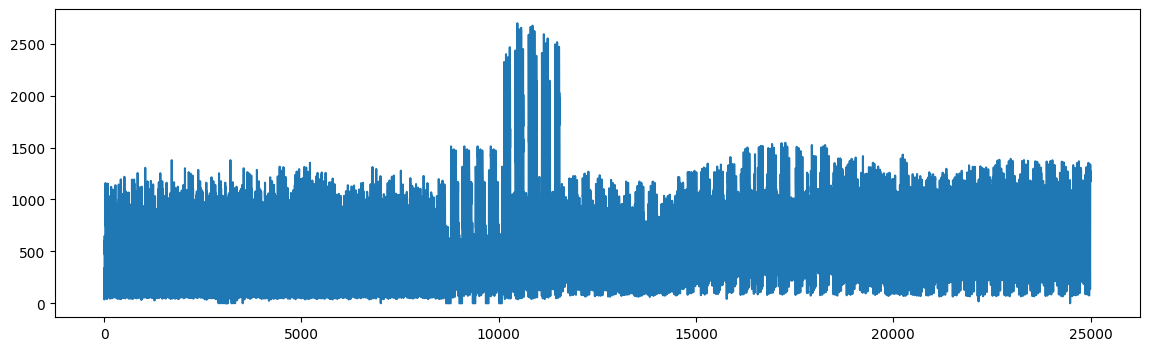

In [21]:
fig, ax =  plt.subplots(figsize=(14,4),ncols=1,nrows=1)
plt.plot(madrid[:])
plt.show()

Самостоятельно реализуйте функцию, принимающую на вход многомерный временной ряд и возвращающий:
1. Все подпоследовательности временного ряда, в которых некоторые значения временного ряда были заменены nan значениями.
2. Индексы пропущенных значений
   
Процент пропущенных значений должен регулироваться отдельным параметром.


In [22]:
import torch
import copy
import random

def add_nan(x, percent = 0.25):
    # Преобразуем входные данные в numpy array
    x_array = np.array(x, dtype=float)

    # Проверяем корректность процента
    if not 0 <= percent <= 1:
        raise ValueError("Процент должен быть в диапозоне от 0 до 1")

    # Определяем общее количество элементов
    total_elements = x_array.size

    # Вычисляем количество элементов для замены на NaN
    num_nan = int(total_elements * percent)

    # Генерируем случайные индексы для замены
    flat_indices = np.random.choice(total_elements, size=num_nan, replace=False)

    # Преобразуем плоские индексы для замены
    missing_indices = []
    x_with_nan = x_array.copy()

    for flat_idx in flat_indices:
        # Преобразуем плоский индекс в многомерный
        if x_array.ndim == 1:
            idx = (flat_idx,)
        else:
            idx = np.unravel_index(flat_idx, x_array.shape)

        # Заменяем значение на Nan
        x_with_nan[idx] = np.nan
        missing_indices.append(idx)

    return x_with_nan, missing_indices

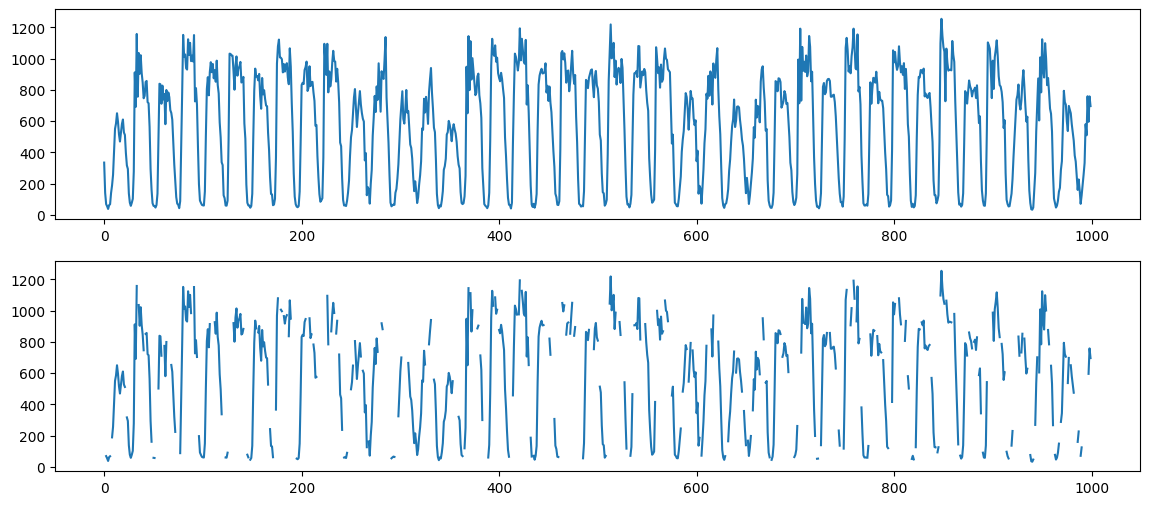

In [23]:
madrid_with_nan, index = add_nan(madrid)
fig, ax =  plt.subplots(figsize=(14,6),ncols=1,nrows=2)
ax[0].plot(madrid[:1000])
ax[1].plot(madrid_with_nan[:1000])
plt.show()

In [25]:
recovery = {}

##### 7.1.2 Заполнение существующими значениями ряда


In [26]:
madrid_mean = madrid_with_nan.copy()
madrid_mean[index] = np.nanmean(madrid_mean)
recovery['mean'] = madrid_mean

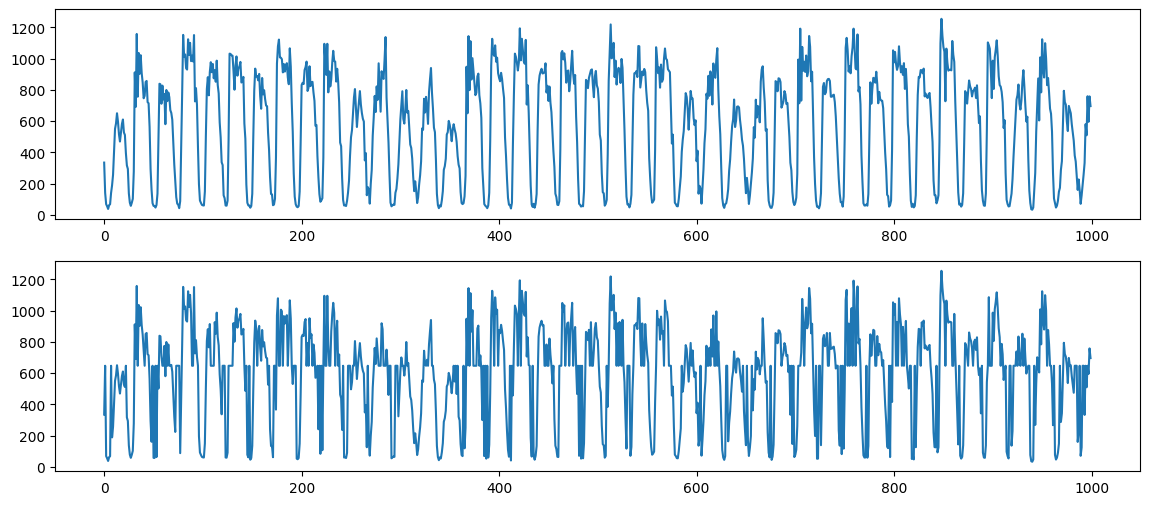

In [27]:
fig, ax =  plt.subplots(figsize=(14,6),ncols=1,nrows=2)
ax[0].plot(madrid[:1000])
ax[1].plot(madrid_mean[:1000])
plt.show()

In [28]:
madrid_median = madrid_with_nan.copy()
madrid_median[index] = np.nanmedian(madrid_median)

In [29]:
recovery['median'] = madrid_median

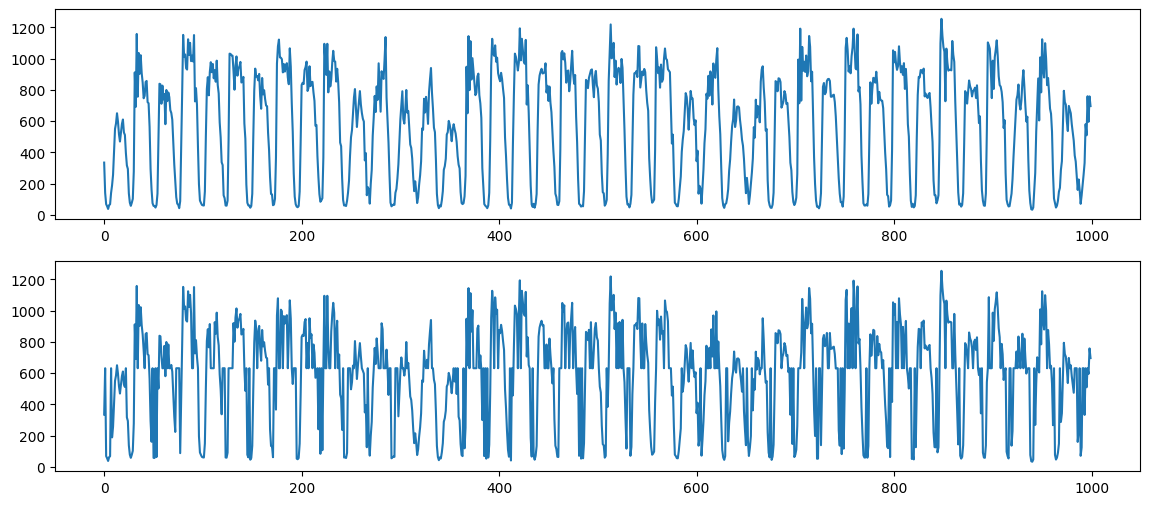

In [30]:
#madrid_with_nan, index = add_nan(madrid)
fig, ax =  plt.subplots(figsize=(14,6),ncols=1,nrows=2)
ax[0].plot(madrid[:1000])
ax[1].plot(madrid_median[:1000])
plt.show()

Самостоятельно реализуйте один метод из первой группы ***табл. 7.1*** и проведите постановление данных, сохранив результаты восстановления.

In [31]:
def hot_deck(ts, missing_indices):
    """
    Функция hot-deck импутации для временных рядов

    Параметры:
    ts: array-like - временной ряд с пропущенными значениями
    missing_indices: array-like - список индексов пропущенных значений

    Возвращает:
    array - временной ряд с заполненными пропусками
    """

    hot_deck_ts = np.array(ts).copy()
    n = len(hot_deck_ts)

    # Создаём булев массив пропущенных значений
    missing_mask = np.full(n, False)
    for idx in missing_indices:
        if len(idx) == 1:
            missing_mask[idx[0]] = True

    for i in range(n):
        if missing_mask[i]:
            found_replacement = False

            # Сначала ищем ближайшее доступное значение справа
            for right_ix in range(i + 1, n):
              if not missing_mask[right_ix]:
                  hot_deck_ts[i] = hot_deck_ts[right_ix]
                  found_replacement = True
                  break

            # Если не нашли справа, ищем слева
            if not found_replacement:
                for left_ix in range(i - 1, -1, -1):
                    hot_deck_ts[i] = hot_deck_ts[left_ix]
                    found_replacement = True
                    break

            # Если не нашли ни одного доступного значения, оставляем как есть
            # (Это может произойти, если все значения пропущены)

    return hot_deck_ts

In [32]:
madrid_hot_deck = hot_deck(madrid_with_nan, index)
recovery['hot_deck'] = madrid_hot_deck

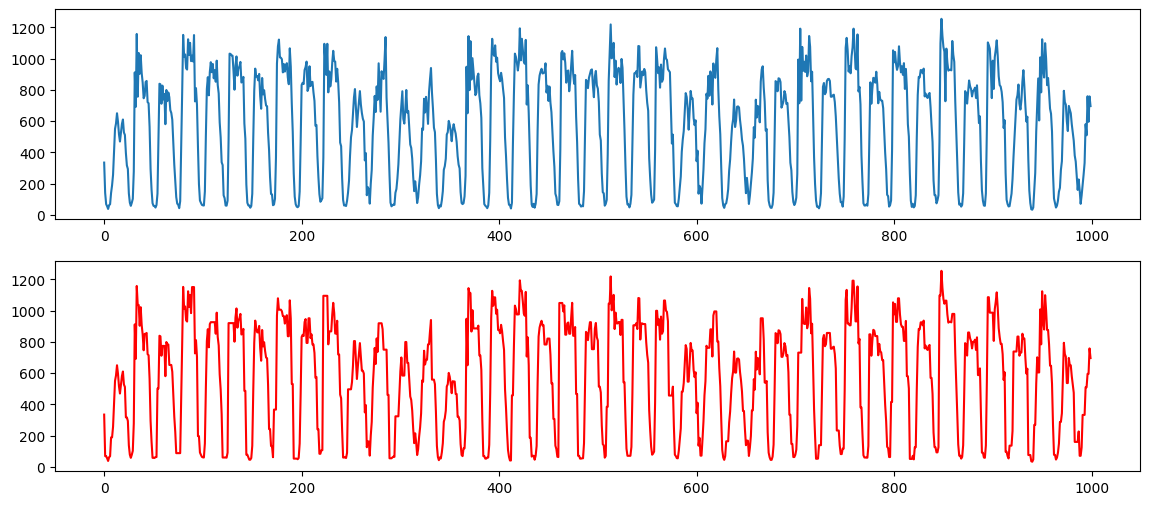

In [33]:
fig, ax =  plt.subplots(figsize=(14,6),ncols=1,nrows=2)
ax[0].plot(madrid[:1000])
ax[1].plot(madrid_hot_deck[:1000], c='red')
plt.show()

##### 7.1.3 Заполнение на основе близких значений


Используя документацию одного из методов восстановления второй группы ***табл. 7.1*** и проведите восстановление данных, сохранив результаты восстановления.

In [34]:
from sklearn.impute import KNNImputer

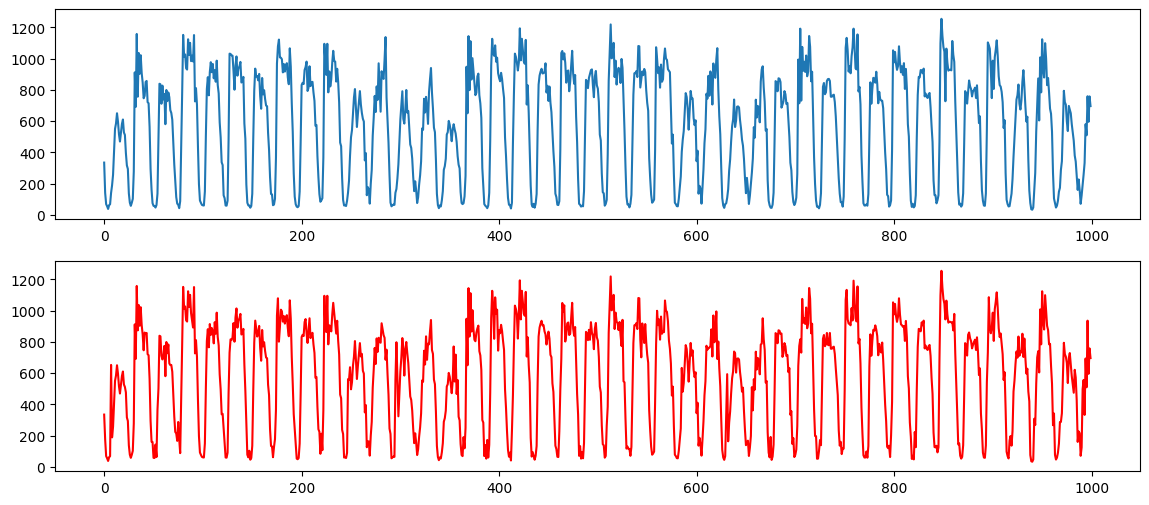

In [35]:
def rolling_window(a, window, intersection=False):
    # result = torch.zeros(size=(a.shape[0],a.shape[1]))
    returns = []
    if intersection:
        for i in range(0, a.shape[0]-window):
            returns.append(a[i:i + window])
    else:
        for i in range(0, a.shape[0],window):
            returns.append(a[i:i + window])
    return np.stack(returns)

madrid_slice = rolling_window(madrid_with_nan, 100)

imputer = KNNImputer(n_neighbors=18)

madrid_knn = imputer.fit_transform(madrid_slice)
madrid_knn = madrid_knn.ravel()

recovery['knn'] = madrid_knn

fig, ax =  plt.subplots(figsize=(14,6),ncols=1,nrows=2)
ax[0].plot(madrid[:1000])
ax[1].plot(madrid_knn[:1000], c='red')
plt.show()

##### 7.1.4 Заполнение на матричных преобразований

Используя документацию одного из методов восстановления третей группы ***табл. 7.1*** и проведите восстановление данных, сохранив результаты восстановления.

In [9]:
!pip install fancyimpute

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 11.4 MB/s eta 0:00:00
  Created wheel for fancyimpute: filename=fancyimpute-0.7.0-py3-none-any.whl size=29879 sha256=33ce1b8613e4b45f50b58b1518465afecb820eddd4dce740e090d36841728856
  Stored in directory: /root/.cache/pip/wheels/df/20/91/e4850b9a31cf660c1bc95515d3bcbc8010e869e5de6d5baf07
  Created wheel for knnimpute: filename=knnimpute-0.1.0-py3-none-any.whl size=11331 sha256=4669f3474b3727107f177ae1a93139d0ab787474a02c692e6a1eba2d716d725a
  Stored in directory: /root/.cache/pip/wheels/89/11/61/aa5a3167bfff49218cd043a73a83034b9eadd858b0059521be
Successfully built fancyimpute knnimpute


In [10]:
from fancyimpute import IterativeSVD

In [11]:
from sklearn.metrics import mean_squared_error

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[IterativeSVD] Iter 1: observed MAE=345.821778
[IterativeSVD] Iter 2: observed MAE=267.594195
[IterativeSVD] Iter 3: observed MAE=259.959261
[IterativeSVD] Iter 4: observed MAE=258.962975
[IterativeSVD] Iter 5: observed MAE=258.757735
[IterativeSVD] Iter 6: observed MAE=258.692363
[IterativeSVD] Iter 7: observed MAE=258.659568


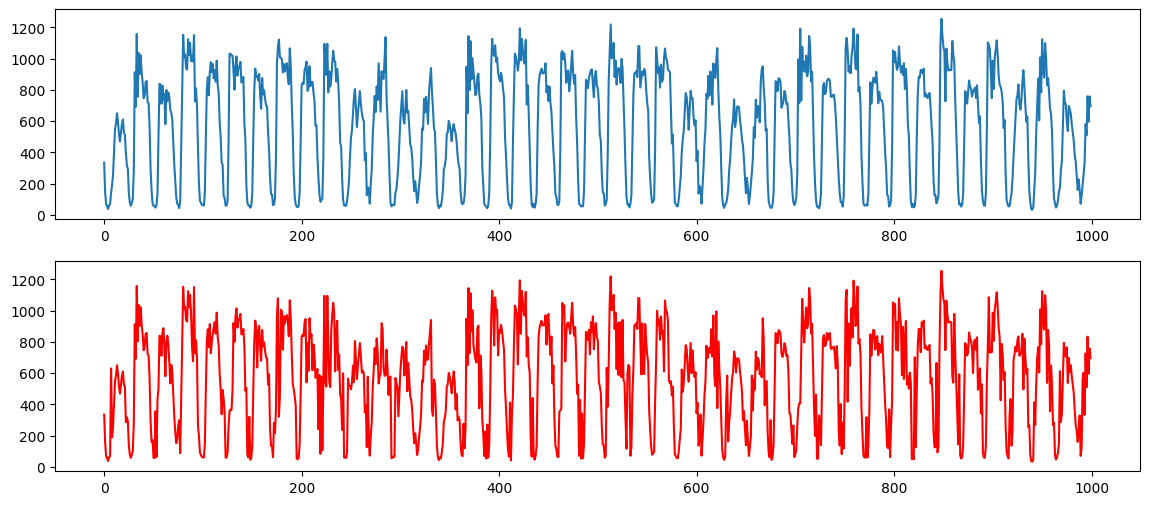

In [36]:
solver = IterativeSVD(rank=2)
madrid_iterative_svd = madrid_slice.copy()
madrid_iterative_svd = solver.fit_transform(madrid_iterative_svd)
madrid_iterative_svd = madrid_iterative_svd.ravel()

recovery['iterative_svd'] = madrid_iterative_svd

fig, ax =  plt.subplots(figsize=(14,6),ncols=1,nrows=2)
ax[0].plot(madrid[:1000])
ax[1].plot(madrid_iterative_svd[:1000], c='red')
plt.show()

##### 7.1.5 Сравнение результатов восстановления.

Для каждой группы методов постройте методов основные метрики оценки качества постановления.
На основе метрик отберите лучшие методы постановления метрик и выберите лучшую группу методов.
Для лучших методов из каждой группы постройте графики сравнения реальных и восстановленных данных. Объясните результаты и сделайте вывод.



In [37]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

print('\n===[mean_squared_error]===')
MSE = {}
for method in recovery:
    MSE[method] = mean_squared_error(madrid, recovery[method])
    print(f"{method}: {MSE[method]}")

print('\n===[mean_absolute_error]===')
MAE = {}
for method in recovery:
    MAE[method] = mean_absolute_error(madrid, recovery[method])
    print(f"{method}: {MAE[method]}")

print('\n===[r2_score]===')
R2 = {}
for method in recovery:
    R2[method] = r2_score(madrid, recovery[method])
    print(f"{method}: {R2[method]}")


===[mean_squared_error]===
mean: 38491.943451699204
median: 38540.28848
hot_deck: 10525.87368
knn: 12355.840471111109
iterative_svd: 27528.711396642357

===[mean_absolute_error]===
mean: 83.6716767488
median: 83.62208
hot_deck: 31.38096
knn: 41.24069777777778
iterative_svd: 67.65606850480405

===[r2_score]===
mean: 0.7536707302767847
median: 0.7533613461707047
hot_deck: 0.9326396501635006
knn: 0.9209287739943671
iterative_svd: 0.8238299559162239


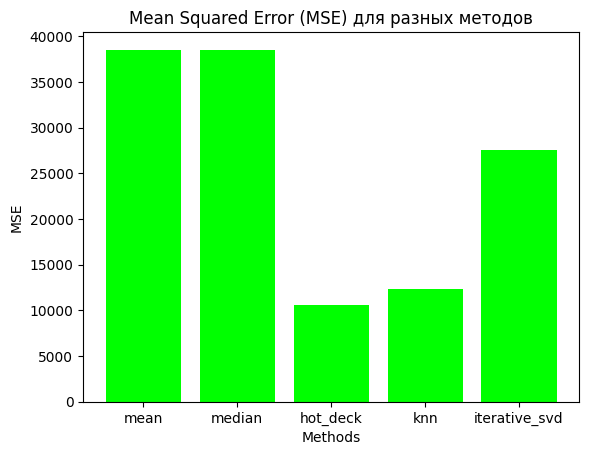

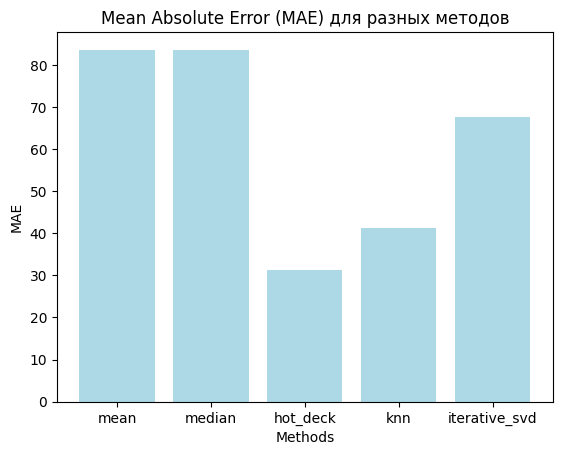

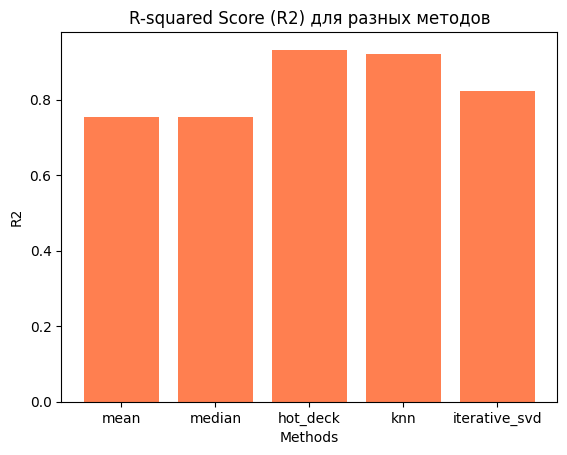

In [38]:
methods = recovery.keys()

# График для MSE
plt.bar(methods, MSE.values(), color='lime')
plt.title('Mean Squared Error (MSE) для разных методов')
plt.xlabel('Methods')
plt.ylabel('MSE')
plt.show()

# График для MAE
plt.bar(methods, MAE.values(), color='lightblue')
plt.title('Mean Absolute Error (MAE) для разных методов')
plt.xlabel('Methods')
plt.ylabel('MAE')
plt.show()

# График для R2
plt.bar(methods, R2.values(), color='coral')
plt.title('R-squared Score (R2) для разных методов')
plt.xlabel('Methods')
plt.ylabel('R2')
plt.show()

*Вывод*:

Методы mean и median подходят лишь как простая базовая оценка. Они не учитывают корреляции между временными точками, поэтому ошибки высокие.

Iterative SVD показал умеренное улучшение но при восстановлении временных рядов может терять информацию из-за линейных предположений модели.

KNN можно считать оптимальным методом для восстановления пропусков во временном ряду, так как он демонстрирует наилучший баланс по метрикам MSE и R^2, которые являются ключевыми для оценки общей точности.

Hot-Deck является очень достойной альтернативой, особенно если критично избегать больших единичных ошибок (что отражает MAE).

Однако, рассматривать данные методы как полноценный инструмент для восстановления не стоит, лучше выбрать нейросетевые методы, которые идут ниже.

#### **7.2 Нейросетевые методы востановления временного ряда**

##### *Краткое описание*

В данном пункте практической работы вам предстоит познакомиться с некоторыми нейросетевыми методами восстановления временных рядов.
Для выполнения данного пункта вам предстоит самостоятельно реализовать структуру нейросетевой, модели основанной на GRU нейронах и сравнить ее с другими нейросетевыми методами восстановления При сравнении с 3 группой из **табл.7. 2** вам необходимо выбрать **один** метод восстановления. Основные блоки обработки данных будут реализованы с использованием Pytorch. Вам не запрещается использовать для реализации Keras.

**табл. 7.2** - Нейросетевые методы восстановления.
№|Название группы|Модели и методы|
--|-------------|----|
1|Линейные нейроны|[Pytorch](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html)|
 2eкрркуретные нейронны|[Pytorch](https://pytorch.org/docs/stable/generated/torch.nn.GRU.html)|
3|Сложные структуры|[SAITS, BRITS, M-RNN](https://github.com/WenjieDu/PyPOTS)|

In [12]:
recovery_nn = {}

##### 7.2.1 Загрузка и подготовка данных

In [39]:
path_data = f'{practice_dir_path}/datasets/madrid.txt'
#path_data = Path('Dataset')/'madrid.txt'
madrid = np.loadtxt(path_data)[:,:]
print(madrid.shape)

(25000, 10)


In [40]:
import numpy as np
import torch

def add_nan(x, percent=0.25):
    # Проверяем, torch это или numpy
    if isinstance(x, torch.Tensor):
        device = x.device
        x_array = x.detach().cpu().numpy()
    else:
        device = 'cpu'
        x_array = np.array(x, dtype=float)

    # Проверяем корректность процента
    if not 0 <= percent <= 1:
        raise ValueError("Процент должен быть в диапозоне от 0 до 1")

    # Создаём маску NaN
    mask = np.random.rand(*x_array.shape) < percent
    x_with_nan = x_array.copy()
    x_with_nan[mask] = 0

    # Возвращаем обратно тензор на исходное устройство
    return torch.tensor(x_with_nan, dtype=torch.float32, device=device), mask


In [41]:
madrid_with_nan, index = add_nan(madrid, 0.25)

In [42]:
madrid_with_nan.shape

torch.Size([25000, 10])

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
madrid_normal_with_nan = scaler.fit_transform(madrid_with_nan)
rolling_madrid = rolling_window(madrid_normal_with_nan, 100, True)
train, test = train_test_split(rolling_madrid,shuffle=False, test_size=0.33)

##### 7.2.2 Базовая модель восстановления данных, построенная на нескольких слоях линейных нейронов.


Вам необходимо будет самостоятельно реализовать:
1. инициализацию nan значений какими либо другими значениями.
2. замер времени полного обучения и тестирования модели.

In [44]:
import torch
from torch import nn
from torch.utils.data import DataLoader

In [45]:
class LinearModel(nn.Module):
    def __init__(self, size_subsequent: int,dim = 1, nums_layers = 3, size_layers = 250):
        super().__init__()

        self.size_subsequent = size_subsequent
        self.nums_layers = nums_layers*dim
        self.dim = dim
        self.size_layers = size_layers

        self.start_layers = nn.Sequential(nn.Flatten(),
                                          nn.Linear(size_subsequent*dim, self.size_layers),
                                          nn.LeakyReLU())
        self.model = nn.ModuleList([
                                        (nn.Sequential(
                                                nn.Linear(self.size_layers, self.size_layers), nn.LeakyReLU()
                                            )
                                        )
                                    for x in torch.arange(nums_layers)])
        self.model = nn.Sequential(*self.model)

        self.output = nn.Sequential(nn.Linear(self.size_layers,size_subsequent*dim),nn.Tanh())

    def forward(self, x):
        x = self.start_layers(x)

        x=self.model(x)
        x=self.output(x)
        return x.reshape(x.shape[0],self.size_subsequent,self.dim)

In [46]:
model = LinearModel(size_subsequent=train.shape[1],dim=train.shape[2])
optimizer = torch.optim.Adam(model.parameters(),lr=1.0e-3)
loss_func = nn.MSELoss()
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
batch_size = 64
percent = 0.25

train_loader = DataLoader(train,batch_size=batch_size,shuffle=True)
valid_loader = DataLoader(test,batch_size=batch_size,shuffle=True)

print(train.shape,test.shape)
epochs = 100

(16683, 100, 10) (8217, 100, 10)


In [47]:
model

LinearModel(
  (start_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1000, out_features=250, bias=True)
    (2): LeakyReLU(negative_slope=0.01)
  )
  (model): Sequential(
    (0): Sequential(
      (0): Linear(in_features=250, out_features=250, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
    )
    (1): Sequential(
      (0): Linear(in_features=250, out_features=250, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
    )
    (2): Sequential(
      (0): Linear(in_features=250, out_features=250, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
    )
  )
  (output): Sequential(
    (0): Linear(in_features=250, out_features=1000, bias=True)
    (1): Tanh()
  )
)

In [48]:
import time
times_model = {}

In [49]:
model=model.to(device)
train_history = []
valid_history = []

start = time.time()
for epoch in np.arange(epochs):
    train_loss =0
    valid_loss =0

    for i, x in enumerate(train_loader):
        if x.shape[0] == batch_size:
            optimizer.zero_grad()
            x = x.to(device).to(torch.float32)
            test_index = np.isnan(x.cpu().numpy())
            X = x.clone()
            X, nan = add_nan(X,percent)
            ###вставте инициализацию нулями nan значений
            recovery = model(X)
            loss = loss_func(recovery[(nan)&(~test_index)],x[(nan)&(~test_index)])
            train_loss += loss.detach().cpu().item()
            loss.backward()
            optimizer.step()
    train_loss/=(i+1)
    print('valid')
    with torch.no_grad():
        for i, x in enumerate(valid_loader):
            if x.shape[0] == batch_size:
                x = x.to(device).to(torch.float32)
                test_index = np.isnan(x.cpu().numpy())
                X = x.clone()
                X, nan = add_nan(X,percent)
                X[torch.isnan(X)]=0.0
                recovery = model(X)
                loss = loss_func(recovery[(nan)&(~test_index)],x[(nan)&(~test_index)])
                valid_loss += loss.detach().cpu().item()
    valid_loss/=(i+1)
    train_history.append(train_loss)
    valid_history.append(valid_loss)
    print(f'epoch:{epoch+1} train:{train_loss*100:.4f}, valid:{valid_loss*100:.4f}')
end = time.time()

valid
epoch:1 train:2.4952, valid:2.4210
valid
epoch:2 train:2.1059, valid:2.3492
valid
epoch:3 train:2.0321, valid:2.2734
valid
epoch:4 train:1.9480, valid:2.2146
valid
epoch:5 train:1.9074, valid:2.1905
valid
epoch:6 train:1.8815, valid:2.1681
valid
epoch:7 train:1.8637, valid:2.1561
valid
epoch:8 train:1.8457, valid:2.1505
valid
epoch:9 train:1.8291, valid:2.1422
valid
epoch:10 train:1.8159, valid:2.1326
valid
epoch:11 train:1.8057, valid:2.1230
valid
epoch:12 train:1.7999, valid:2.1131
valid
epoch:13 train:1.7865, valid:2.1126
valid
epoch:14 train:1.7843, valid:2.0972
valid
epoch:15 train:1.7755, valid:2.1026
valid
epoch:16 train:1.7725, valid:2.0978
valid
epoch:17 train:1.7682, valid:2.0937
valid
epoch:18 train:1.7650, valid:2.0796
valid
epoch:19 train:1.7585, valid:2.0922
valid
epoch:20 train:1.7536, valid:2.0802
valid
epoch:21 train:1.7512, valid:2.0889
valid
epoch:22 train:1.7461, valid:2.0766
valid
epoch:23 train:1.7440, valid:2.0770
valid
epoch:24 train:1.7436, valid:2.0743
v

In [50]:
times_model['linear']=end-start

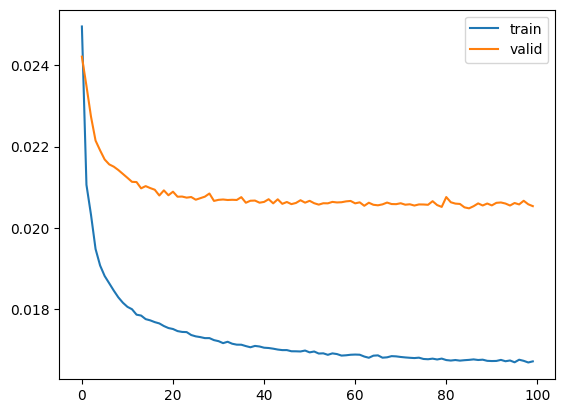

In [51]:
plt.plot(train_history,label='train')
plt.plot(valid_history,label='valid')
plt.legend()
plt.show()

In [52]:
test_rolling_madrid = rolling_window(madrid_normal_with_nan, 100, False)
#test = []
with torch.no_grad():
    for idx, batch in enumerate(test_rolling_madrid):
        batch = torch.Tensor(batch).to(device)
        nan = torch.isnan(batch)
        batch[nan]=0.0
        rec = model(batch[None,:])[0].cpu().numpy()
        nan = nan.cpu().numpy()
        test_rolling_madrid[idx][nan]=rec[nan]

In [53]:
test_madrid_normal = np.vstack(test_rolling_madrid)
test_linear = scaler.inverse_transform(test_madrid_normal)

In [54]:
recovery_nn['linear'] = test_linear

415163.14110223105


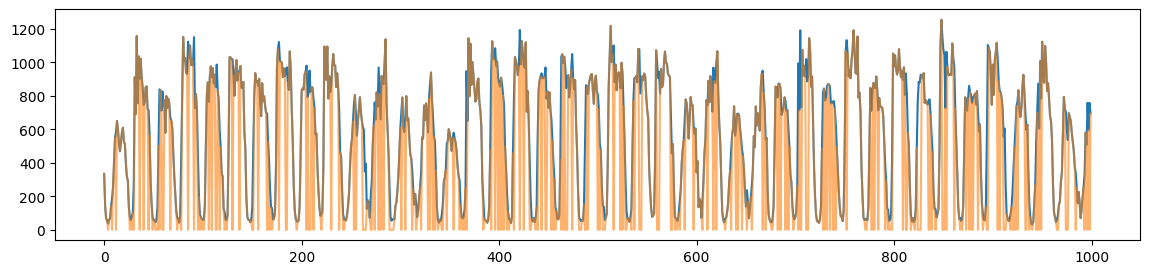

In [55]:
fig, ax =  plt.subplots(figsize=(14,3),ncols=1,nrows=1)

plt.plot(madrid[:1000,0])
plt.plot(test_linear[:1000,0],alpha=0.6)
print(mean_squared_error(madrid[index].reshape(1,-1),test_linear[index].reshape(1,-1)))

##### 7.2.3 Реккурентная модель востановлениях данных


In [56]:
class EncoderGRU(nn.Module):
    def __init__(self, size_subsequent: int, dim = 1, latten_size = 100, hidden_size=100):
        super().__init__()
        self.size_subsequent=size_subsequent
        self.dim = dim
        self.hidden_size = hidden_size
        self.gru = nn.GRU(input_size=dim,
                          hidden_size=self.hidden_size)

        self.latten = nn.Linear(hidden_size*size_subsequent,latten_size)
        self.leaky = nn.LeakyReLU()
        self.fl = nn.Flatten()
    def forward(self, x):
        x, _ = self.gru(x)
        x = self.leaky(x)
        #print(x.shape)
        x = self.fl(x)
        x = self.latten(x)
        return self.leaky(x)


In [57]:
class DecoderGRU(nn.Module):
    def __init__(self, size_subsequent: int, dim = 1, latten_size = 100, hidden_size=100):
        super().__init__()
        self.size_subsequent=size_subsequent
        self.dim = dim
        self.hidden_size = hidden_size
        self.latten_size=latten_size
        self.gru = nn.GRU(input_size=self.hidden_size,
                          hidden_size=dim)
        self.latten = nn.Linear(latten_size,hidden_size*size_subsequent)
        self.leaky = nn.LeakyReLU()

    def forward(self, x):
        x = self.latten(x)
        x = x.view(-1, self.size_subsequent, self.latten_size)
        x = self.leaky(x)
        x, _ = self.gru(x)
        return self.leaky(x)


In [58]:
class TimeAE(nn.Module):
    def __init__(self, size_subsequent: int, dim = 1, latten_size = 100, hidden_size=100):
        super().__init__()
        self.encoder = EncoderGRU(size_subsequent=size_subsequent,
                                 dim=dim,
                                 latten_size=latten_size,
                                 hidden_size=hidden_size)
        self.decoder = DecoderGRU(size_subsequent=size_subsequent,
                                 dim=dim,
                                 latten_size=latten_size,
                                 hidden_size=hidden_size)
    def forward(self, x):
        x=self.encoder(x)
        x = self.decoder(x)
        return x

In [59]:
model = TimeAE(size_subsequent=train.shape[1],dim=train.shape[2])
optimizer = torch.optim.Adam(model.parameters(),lr=1.0e-3)
loss_func = nn.MSELoss()
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
batch_size = 64
percent = 0.25

train_loader = DataLoader(train,batch_size=batch_size,shuffle=True)
valid_loader = DataLoader(test,batch_size=batch_size,shuffle=True)


epochs = 100

In [60]:
model

TimeAE(
  (encoder): EncoderGRU(
    (gru): GRU(10, 100)
    (latten): Linear(in_features=10000, out_features=100, bias=True)
    (leaky): LeakyReLU(negative_slope=0.01)
    (fl): Flatten(start_dim=1, end_dim=-1)
  )
  (decoder): DecoderGRU(
    (gru): GRU(100, 10)
    (latten): Linear(in_features=100, out_features=10000, bias=True)
    (leaky): LeakyReLU(negative_slope=0.01)
  )
)

In [61]:
model=model.to(device)
train_history = []
valid_history = []
start = time.time()
for epoch in np.arange(epochs):
    train_loss =0
    valid_loss =0

    for i, x in enumerate(train_loader):
        if x.shape[0]==batch_size:
            optimizer.zero_grad()
            x = x.to(device).to(torch.float32)
            test_index = np.isnan(x.cpu().numpy())
            X = x.clone()
            X, nan = add_nan(X,percent)
            #

            recovery = model(X)
            loss = loss_func(recovery[(nan)&(~test_index)],x[(nan)&(~test_index)])
            train_loss += loss.detach().cpu().item()
            loss.backward()
            optimizer.step()
    train_loss/=(i+1)
    with torch.no_grad():
        for i, x in enumerate(valid_loader):
            if x.shape[0]==batch_size:
                x = x.to(device).to(torch.float32)
                test_index = np.isnan(x.cpu().numpy())
                X = x.clone()
                X, nan = add_nan(X,percent)
                #

                recovery = model(X)
                loss = loss_func(recovery[(nan)&(~test_index)],x[(nan)&(~test_index)])
                valid_loss += loss.detach().cpu().item()
    valid_loss/=(i+1)
    train_history.append(train_loss)
    valid_history.append(valid_loss)
    print(f'epoch:{epoch+1} train:{train_loss}, valid:{valid_loss}')
end = time.time()

epoch:1 train:0.029432923029894115, valid:0.023819074756646342
epoch:2 train:0.020015075931261325, valid:0.02238422827145388
epoch:3 train:0.019011517165949517, valid:0.021786863980598228
epoch:4 train:0.018493094113994375, valid:0.02146045571958372
epoch:5 train:0.01822778141532821, valid:0.02126022878774377
epoch:6 train:0.01801167362123385, valid:0.02121277739719827
epoch:7 train:0.01784033970586185, valid:0.020925873731688936
epoch:8 train:0.0177297853647064, valid:0.020958460131010343
epoch:9 train:0.017614217821180365, valid:0.02080573625285034
epoch:10 train:0.0175255851042225, valid:0.020880300060723177
epoch:11 train:0.017440039753714054, valid:0.02075759473061839
epoch:12 train:0.017399887254611515, valid:0.020723456256957942
epoch:13 train:0.01732553756827938, valid:0.02061858472898025
epoch:14 train:0.017288612059078456, valid:0.020597072996834453
epoch:15 train:0.017215080930355408, valid:0.020573131610141245
epoch:16 train:0.01714842140646045, valid:0.020568587521249935
e

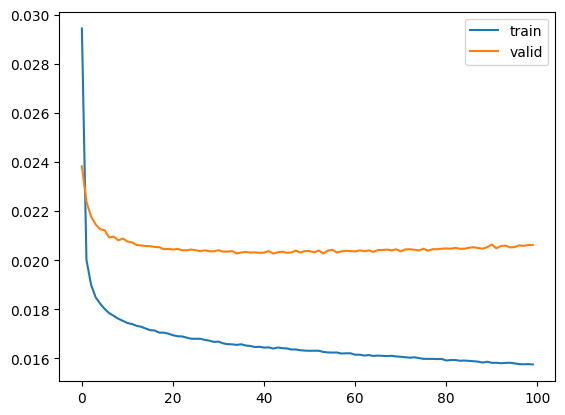

In [62]:
plt.plot(train_history,label='train')
plt.plot(valid_history,label='valid')
plt.legend()
plt.show()

In [63]:
times_model['ae']=end-start

In [64]:
test_rolling_madrid = rolling_window(madrid_normal_with_nan, 100, False)
#test = []
with torch.no_grad():
    for idx, batch in enumerate(test_rolling_madrid):
        batch = torch.Tensor(batch).to(device)
        nan = torch.isnan(batch)
        #

        rec = model(batch[None,:])[0].cpu().numpy()
        nan = nan.cpu().numpy()
        test_rolling_madrid[idx][nan]=rec[nan]

In [65]:
test_madrid_normal = np.vstack(test_rolling_madrid)
test_ae = scaler.inverse_transform(test_madrid_normal)

In [66]:
recovery_nn['test_ae'] = test_ae

415163.14110223105


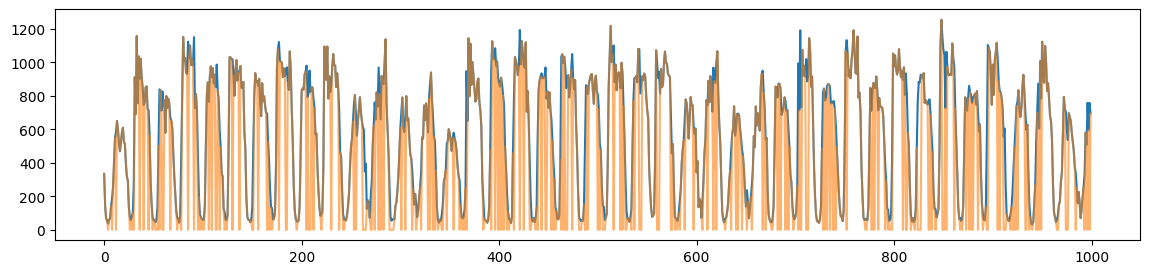

In [67]:
fig, ax =  plt.subplots(figsize=(14,3),ncols=1,nrows=1)

plt.plot(madrid[:1000,0])
plt.plot(test_ae[:1000,0],alpha=0.6)
print(mean_squared_error(madrid[index].reshape(1,-1),test_ae[index].reshape(1,-1)))

##### 7.2.4 Сложные модели нейросетевого восстановления данных


Вам необходимо выбрать одну модель из 3 группы таблицы 7.2 и используя документацию произвести восстановления того же ряда. Произведите замер времени.

In [68]:
!pip install pypots==0.0.9

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.6/81.6 kB 5.5 MB/s eta 0:00:00


In [69]:
from pypots.imputation import SAITS


2025-11-19 13:14:35 [WARNING]: ‼️ PyPOTS Ecosystem configuration file does not exist.
2025-11-19 13:14:35 [INFO]: Wrote new configs to config.ini successfully.
2025-11-19 13:14:35 [INFO]: 💫 Initialized PyPOTS Ecosystem configuration file /root/.pypots/config.ini successfully.


In [70]:
model= SAITS(n_features=madrid.shape[1],
             n_steps=100,
             device=device,
             d_k=64,
             d_v=64,
             d_model=128,
             d_inner=128,
             n_head=4,
             n_layers=2,
             dropout=0.05,
             epochs=100)

Model initialized successfully. Number of the trainable parameters: 667608


In [71]:
start = time.time()
model.fit(train,test)
end = time.time()
times_model['saits']=end-start

epoch 0: training loss 0.2159, validating loss 0.1014
epoch 1: training loss 0.1582, validating loss 0.0950
epoch 2: training loss 0.1462, validating loss 0.0911
epoch 3: training loss 0.1406, validating loss 0.0894
epoch 4: training loss 0.1300, validating loss 0.0886
epoch 5: training loss 0.1099, validating loss 0.0854
epoch 6: training loss 0.1010, validating loss 0.0863
epoch 7: training loss 0.0991, validating loss 0.0842
epoch 8: training loss 0.0977, validating loss 0.0837
epoch 9: training loss 0.0963, validating loss 0.0845
epoch 10: training loss 0.0953, validating loss 0.0835
epoch 11: training loss 0.0948, validating loss 0.0838
epoch 12: training loss 0.0943, validating loss 0.0822
epoch 13: training loss 0.0938, validating loss 0.0828
epoch 14: training loss 0.0935, validating loss 0.0822
epoch 15: training loss 0.0930, validating loss 0.0821
epoch 16: training loss 0.0928, validating loss 0.0824
epoch 17: training loss 0.0924, validating loss 0.0816
epoch 18: training l

In [72]:
test_rolling_madrid = rolling_window(madrid_normal_with_nan, 100, False)
test_rolling_madrid = model.impute(test_rolling_madrid)


In [73]:
test_madrid_normal = np.vstack(test_rolling_madrid)
test_saits = scaler.inverse_transform(test_madrid_normal)

In [74]:
recovery_nn['saits'] = test_saits

415163.14110223105


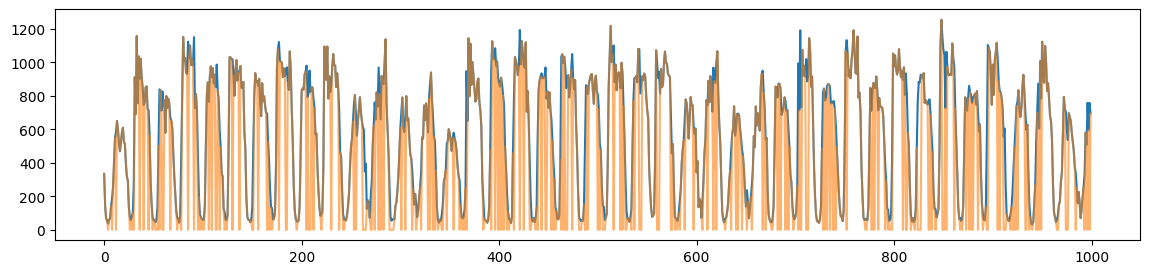

In [75]:
fig, ax =  plt.subplots(figsize=(14,3),ncols=1,nrows=1)

plt.plot(madrid[:1000,0])
plt.plot(test_saits[:1000,0],alpha=0.6)
print(mean_squared_error(madrid[index].reshape(1,-1),test_saits[index].reshape(1,-1)))

##### 7.2.5 Сравнения результатов.
Также, как и в пункте 7.1.5 постройте графики сравнения моделей. Дополнительно постройте графики сравнения времени. Сделайте выводы

In [81]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd

metrics_dict = {}

for model_name, recovery_data in recovery_nn.items():
    y_true = madrid[index].reshape(1,-1)
    y_pred = recovery_data[index].reshape(1,-1)

    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(madrid[index], recovery_data[index])

    metrics_dict[model_name] = {'MSE': mse, 'MAE': mae, 'R2': r2}

metrics_df = pd.DataFrame(metrics_dict).T
print('Метрики качества восстановления (только на пропущенных точках):')
print(metrics_df.round(6))



Метрики качества восстановления (только на пропущенных точках):
                   MSE         MAE        R2
linear   415163.141102  480.546775 -1.253407
test_ae  415163.141102  480.546775 -1.253407
saits    415163.141102  480.546775 -1.253407


In [82]:
for model_name, t in times_model.items():
    if model_name in metrics_df.index:
        metrics_df.loc[model_name, 'Time (s)'] = t

metrics_df.loc['test_ae', 'Time (s)'] = times_model['ae']
print('\nСводная таблица результатов (Метрики + Время):')
print(metrics_df.round(6))


Сводная таблица результатов (Метрики + Время):
                   MSE         MAE        R2     Time (s)
linear   415163.141102  480.546775 -1.253407   181.374151
test_ae  415163.141102  480.546775 -1.253407   215.385720
saits    415163.141102  480.546775 -1.253407  1595.473531


In [84]:
import matplotlib.pyplot as plt

best_model_mse = metrics_df['MSE'].idxmin()
best_model_r2 = metrics_df['R2'].idxmax()

print(f'Лучший метод по MSE: {best_model_mse}')
print(f'Лучший метод по R2: {best_model_r2}')

Лучший метод по MSE: linear
Лучший метод по R2: linear


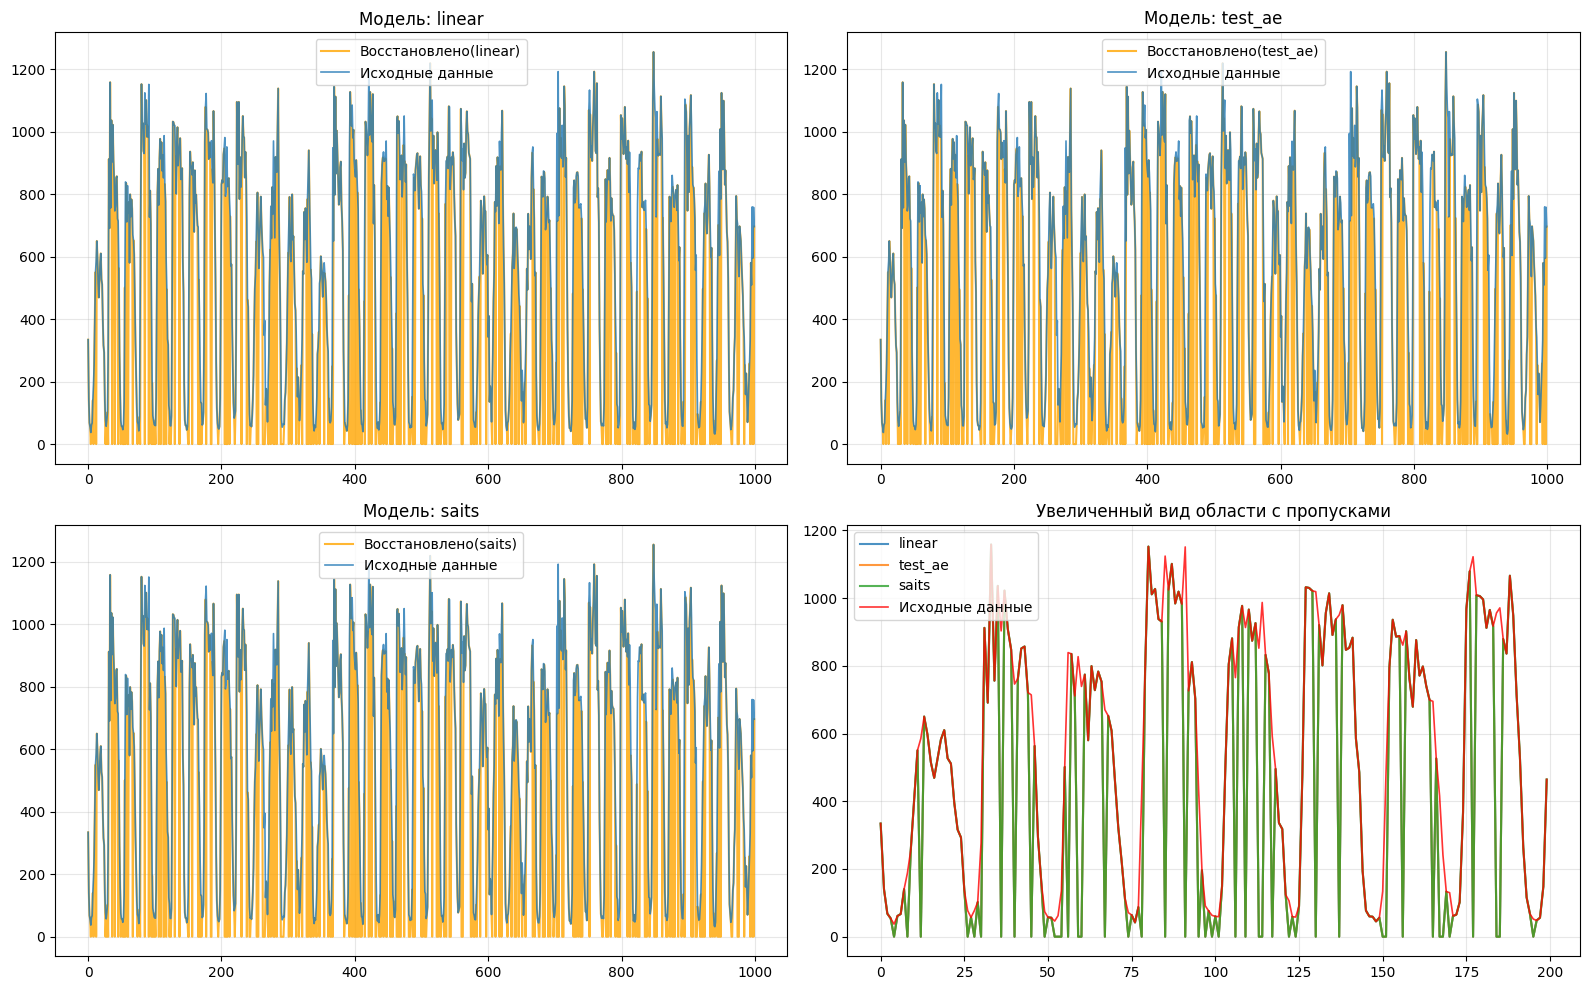

In [105]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

top_models = metrics_df.nsmallest(3, 'MSE').index

zoom_start = 0
zoom_end = 1000

up_start = 0
up_end = 200

for i, model_name in enumerate(top_models):
    recovered_data = recovery_nn[model_name]
    axes[i].plot(
        recovered_data[zoom_start:zoom_end, 0],
        label=f'Восстановлено({model_name})',
        alpha=0.8,
        linewidth=1.5,
        color='orange'
    )
    axes[i].plot(
        madrid[zoom_start:zoom_end, 0],
        label='Исходные данные',
        alpha=0.8,
        linewidth=1.2
    )
    axes[i].set_title(f'Модель: {model_name}')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

for i, model_name in enumerate(top_models):
    recovered_data = recovery_nn[model_name]
    axes[3].plot(recovered_data[up_start:up_end, 0], label=f'{model_name}', alpha=0.8, linewidth=1.5)
axes[3].plot(madrid[up_start:up_end, 0], label='Исходные данные', alpha=0.8, linewidth=1.2, color='red')
axes[3].set_title('Увеличенный вид области с пропусками')
axes[3].legend()
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

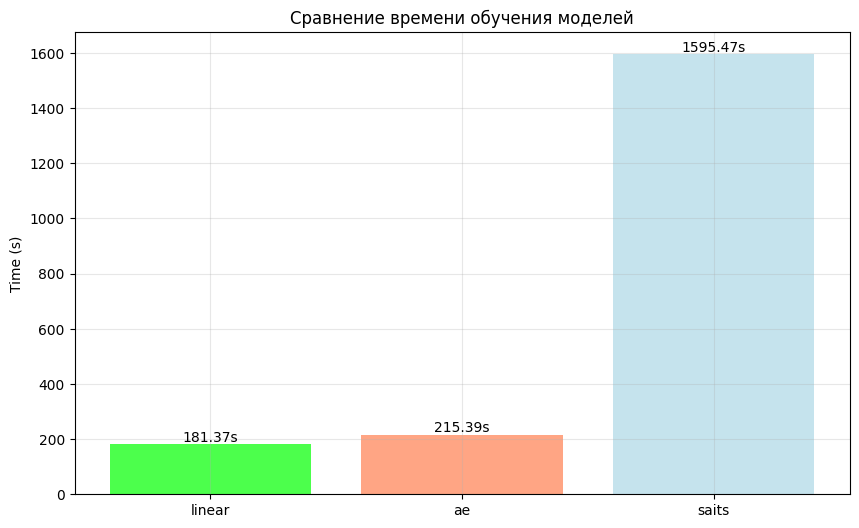

In [109]:
plt.figure(figsize=(10,6))
times_series = pd.Series(times_model)
colors = ['lime', 'coral', 'lightblue']

bars = plt.bar(times_series.index, times_series.values, color=colors, alpha=0.7)
plt.ylabel('Time (s)')
plt.title('Сравнение времени обучения моделей')
plt.grid(True, alpha=0.3)

for bar, time_val in zip(bars, times_series.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, f'{time_val:.2f}s', ha='center', va='bottom')

plt.show()

Все три модели - Linear, Autoencoder и SAITS показали одинаковые метрики:

MSE = 415163.141102  
MAE = 480.546775
R^2 = -1.253407

Это говорит о том, что ни одна из моделей не смогла адекватно восстановить пропущенные значения. Отрицательное значение R^2 означает, что качество хуже, чем у простой модели, предсказывающей среднее значение.

На всех трёх графиках восстановленные значения сильно отклоняются от исходных данных, что подтверждает неудачное восстановление. На увеличенном участке видно, что линии моделей почти полностью совпадают между собой, что объясняет идентичные метрики.

При этом качество всех моделей одинаковое, но SAITS оказался во много раз медленнее, что делает его неэффективным в данной ситуации.

#### **7.3 Прогноз временного ряда**

##### *Краткое описание*

Используя модель и [ARIMA](реализация) произвидите прогноз ряда на следующие колличество точек: 1, 5, 10.
Сравните результаты. Постройте графики прогноза и точности прогноза.

In [111]:
path_data = f'{practice_dir_path}/datasets/madrid.txt'
madrid = np.loadtxt(path_data)[:,:]
print(madrid.shape)

madrid_with_nan, index = add_nan(madrid, 0.25)

(25000, 10)


In [112]:
def rolling_window(a, window, intersection=False):
    returns = []
    if intersection:
        for i in range(0, a.shape[0]-window):
            returns.append(a[i:i + window])
    else:
        for i in range(0, a.shape[0],window):
            returns.append(a[i:i + window])
    return np.stack(returns)

In [113]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
madrid_normal_with_nan = scaler.fit_transform(madrid_with_nan)
rolling_madrid = rolling_window(madrid_normal_with_nan, 100, True)
train, test = train_test_split(rolling_madrid, shuffle=False, test_size=0.33)

In [115]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings

In [116]:
def prepare_arima_data(data, column_idx=0):
    ts_data = data[:, column_idx]
    ts_data_clean = ts_data[~np.isnan(ts_data)]
    return ts_data_clean

In [117]:
train_arima = prepare_arima_data(train)
test_arima = prepare_arima_data(test)
print(f'Размер тренеровочных данных {len(train_arima)}')
print(f'Размер тестовых данных {len(test_arima)}')

Размер тренеровочных данных 166830
Размер тестовых данных 82170


In [118]:
model = ARIMA(train_arima, order=(3,1,3))
fitted_model = model.fit()
best_model = fitted_model

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [120]:
# Прогнозирование на разные горизонты и оценка точности
def forecast_arima(model, steps_list):
    forecasts = {}
    errors = {}

    for steps in steps_list:
        forecast = model.forecast(steps=steps)

        if steps <= len(test_arima):
            actual = test_arima[:steps]
            mse = mean_squared_error(actual, forecast)
            mae = mean_absolute_error(actual, forecast)
            rmse = np.sqrt(mse)

            errors[steps] = {'MSE': mse, 'MAE': mae, 'RMSE': rmse}

        forecasts[steps] = forecast

    return forecasts, errors

In [121]:
forecast_points = [1, 5, 10]
forecasts, errors = forecast_arima(best_model, forecast_points)

In [123]:
print(f'Сравнение точности прогнозов:\n{'=' * 50}')

for steps in forecast_points:
    if steps in errors:
        print(f'Прогноз на {steps} точек:')
        print(f'Прогноз MSE: {errors[steps]['MSE']:.6f}')
        print(f'Прогноз MAE: {errors[steps]['MAE']:.6f}')
        print(f'Прогноз RMSE: {errors[steps]['RMSE']:.6f}')
    else:
        print(f'Прогноз на {steps} точек: метрики недоступных (недостаточно тестовых данных)')

    print('=' * 50)

Сравнение точности прогнозов:
Прогноз на 1 точек:
Прогноз MSE: 0.000348
Прогноз MAE: 0.018650
Прогноз RMSE: 0.018650
Прогноз на 5 точек:
Прогноз MSE: 0.000341
Прогноз MAE: 0.017113
Прогноз RMSE: 0.018461
Прогноз на 10 точек:
Прогноз MSE: 0.000478
Прогноз MAE: 0.019828
Прогноз RMSE: 0.021868


In [ ]:
# @title
fig, axes = plt.subplots(2,2, figsize=(15,12))
fig.suptitle('Прогнозирование ВР с использованием ARIMA', fontsize=16)

axes[0,0].plot(train_arima[-100:], label = 'Тренеровочные данные (последние 100 точек)')
x_position = range(len(train_arima[-100:]), len(train_arima[-100:]) + len(test_arima[:20]))
axes[0,0].plot(x_position, test_arima[:20], label='Тестовые данные (первые 20 точек)', alpha=0.7)
axes[0,0].set_title('Исходные данные')
axes[0,0].set_xlabel('Время')
axes[0,0].set_ylabel('Значение')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Прогноз на 1 точку
axes[0,1].plot(train_arima[-50:], 'Исторические данные', color='blue')
forecast_1 = forecasts[1]
x_position = len(train_arima[-50:])
axes[0,1].scatter(x_position, forecast_1[0], color='red', s=50, zorder=5, label=f'Прогноз: {forecast_1[0]:.4f}')
if len(test_arima) >= 1:
    axes[0,1].scatter(x_position, test_arima[0], color='lime', s=50, zorder=5, label=f'Факт: {test_arima[0]:.4f}')
axes[0,1].set_title('Прогноз на 1 точку вперёд')
axes[0,1].set_xlabel('Время')
axes[0,1].set_ylabel('Значение')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Прогноз на 5 точек
axes[1,0].plot(train_arima[-30:], 'Исторические данные', color='blue')
forecast_5 = forecasts[5]
x_position = range(len(train_arima[-30:]), len(train_arima[-30:]) + 5)
axes[1,0].scatter(x_position, forecast_5, color='red', marker='o', label=f'Прогноз ARIMA', linewidth=2)
if len(test_arima) >= 5:
    axes[1,0].scatter(x_position, test_arima[:5], color='lime', marker='s', label=f'Фактические значения', linewidth=2)
axes[1,0].set_title('Прогноз на 5 точек вперёд')
axes[1,0].set_xlabel('Время')
axes[1,0].set_ylabel('Значение')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Прогноз на 10 точек
axes[1,1].plot(train_arima[-30:], 'Исторические данные', color='blue')
forecast_10 = forecasts[10]
x_position = range(len(train_arima[-30:]), len(train_arima[-30:]) + 10)
axes[1,1].scatter(x_position, forecast_10, color='red', marker='o', label='Прогноз ARIMA')
if len(test_arima) >= 10:
    axes[1,1].scatter(x_position, test_arima[:10], color='lime', marker='s', label='Фактические значения')
axes[1,1].set_title('Прогноз на 10 точек вперёд')
axes[1,1].set_xlabel('Время')
axes[1,1].set_ylabel('Значение')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

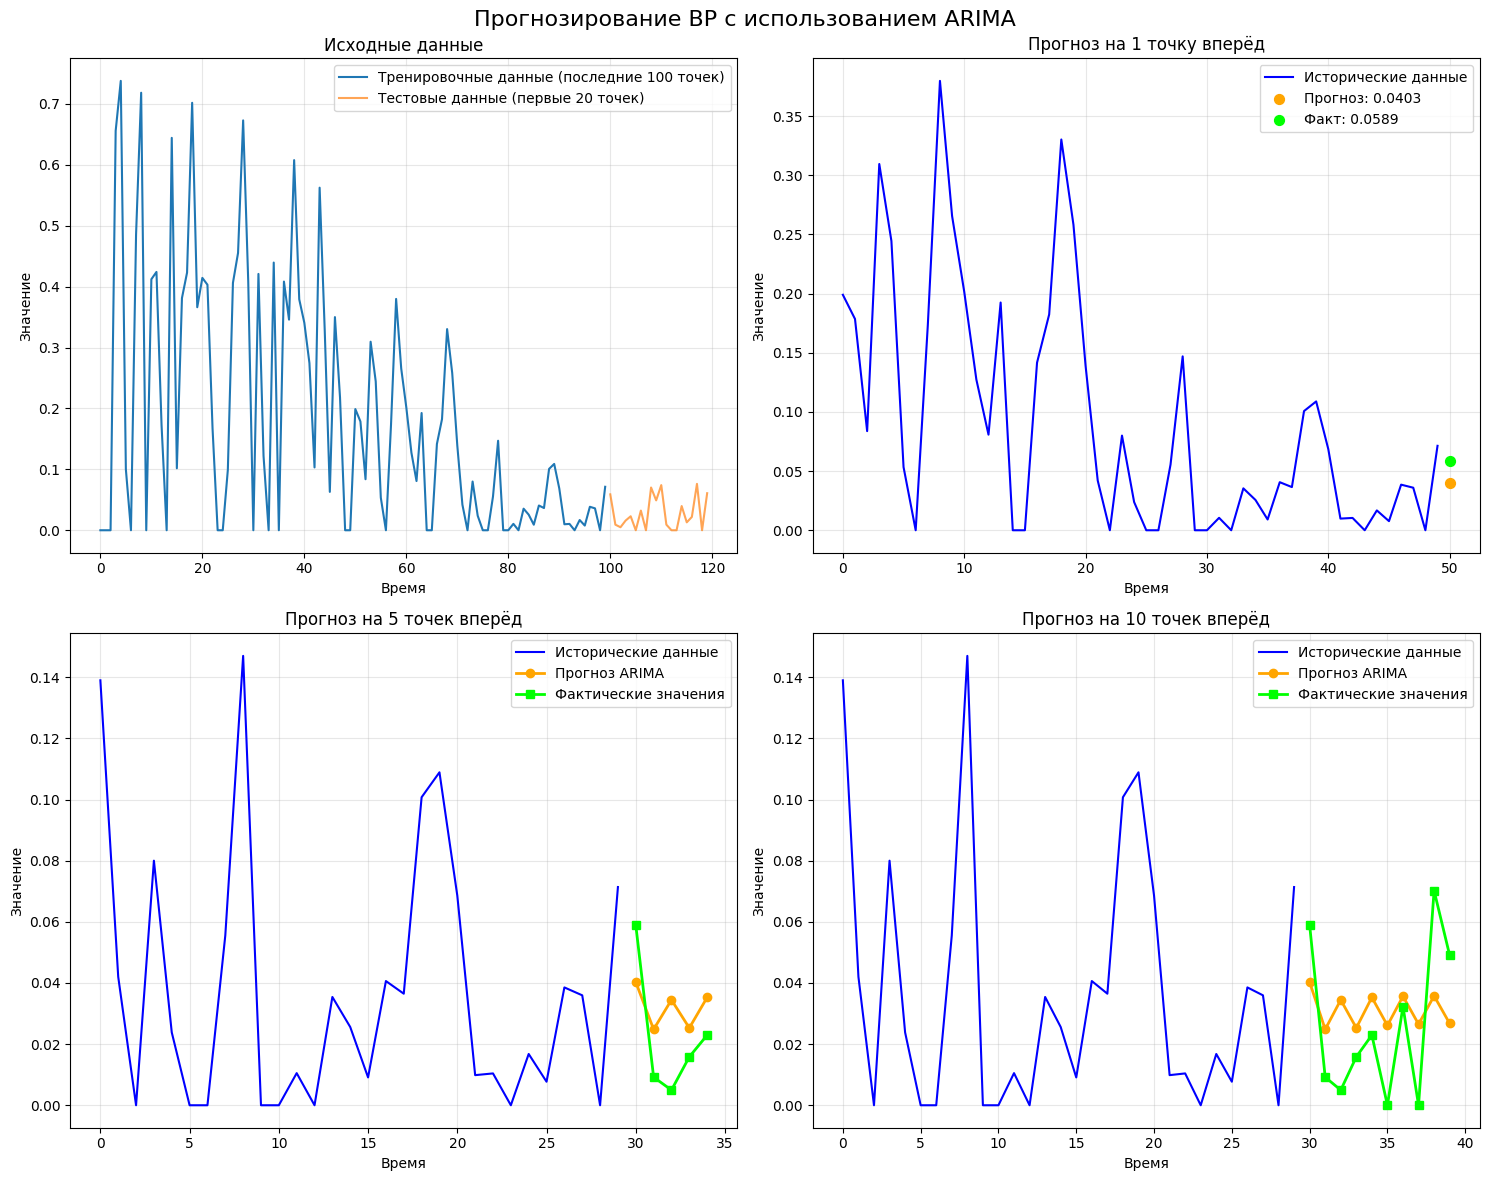

In [133]:
fig, axes = plt.subplots(2,2, figsize=(15,12))
fig.suptitle('Прогнозирование ВР с использованием ARIMA', fontsize=16)

# ----------------------------------------------------
# Исходные данные
# ----------------------------------------------------
axes[0,0].plot(train_arima[-100:], label='Тренировочные данные (последние 100 точек)')
x_position = range(len(train_arima[-100:]), len(train_arima[-100:]) + len(test_arima[:20]))
axes[0,0].plot(x_position, test_arima[:20], label='Тестовые данные (первые 20 точек)', alpha=0.7)

axes[0,0].set_title('Исходные данные')
axes[0,0].set_xlabel('Время')
axes[0,0].set_ylabel('Значение')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# ----------------------------------------------------
# Прогноз на 1 шаг
# ----------------------------------------------------
axes[0,1].plot(train_arima[-50:], label='Исторические данные', color='blue')

forecast_1 = forecasts[1]
x_position = len(train_arima[-50:])

axes[0,1].scatter(x_position, forecast_1[0], color='orange', s=50, zorder=5, label=f'Прогноз: {forecast_1[0]:.4f}')

if len(test_arima) >= 1:
    axes[0,1].scatter(x_position, test_arima[0], color='lime', s=50, zorder=5, label=f'Факт: {test_arima[0]:.4f}')

axes[0,1].set_title('Прогноз на 1 точку вперёд')
axes[0,1].set_xlabel('Время')
axes[0,1].set_ylabel('Значение')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# ----------------------------------------------------
# Прогноз на 5 шагов
# ----------------------------------------------------
axes[1,0].plot(train_arima[-30:], label='Исторические данные', color='blue')

forecast_5 = forecasts[5]
x_position = range(len(train_arima[-30:]), len(train_arima[-30:]) + 5)

axes[1,0].plot(x_position, forecast_5, color='orange', marker='o', linestyle='-', linewidth=2, label='Прогноз ARIMA')

if len(test_arima) >= 5:
    axes[1,0].plot(x_position, test_arima[:5], color='lime', marker='s', linestyle='-', linewidth=2, label='Фактические значения')

axes[1,0].set_title('Прогноз на 5 точек вперёд')
axes[1,0].set_xlabel('Время')
axes[1,0].set_ylabel('Значение')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# ----------------------------------------------------
# Прогноз на 10 шагов
# ----------------------------------------------------
axes[1,1].plot(train_arima[-30:], label='Исторические данные', color='blue')

forecast_10 = forecasts[10]
x_position = range(len(train_arima[-30:]), len(train_arima[-30:]) + 10)

axes[1,1].plot(x_position, forecast_10, color='orange', marker='o', linestyle='-', linewidth=2, label='Прогноз ARIMA')

if len(test_arima) >= 10:
    axes[1,1].plot(x_position, test_arima[:10], color='lime', marker='s', linestyle='-', linewidth=2, label='Фактические значения')

axes[1,1].set_title('Прогноз на 10 точек вперёд')
axes[1,1].set_xlabel('Время')
axes[1,1].set_ylabel('Значение')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

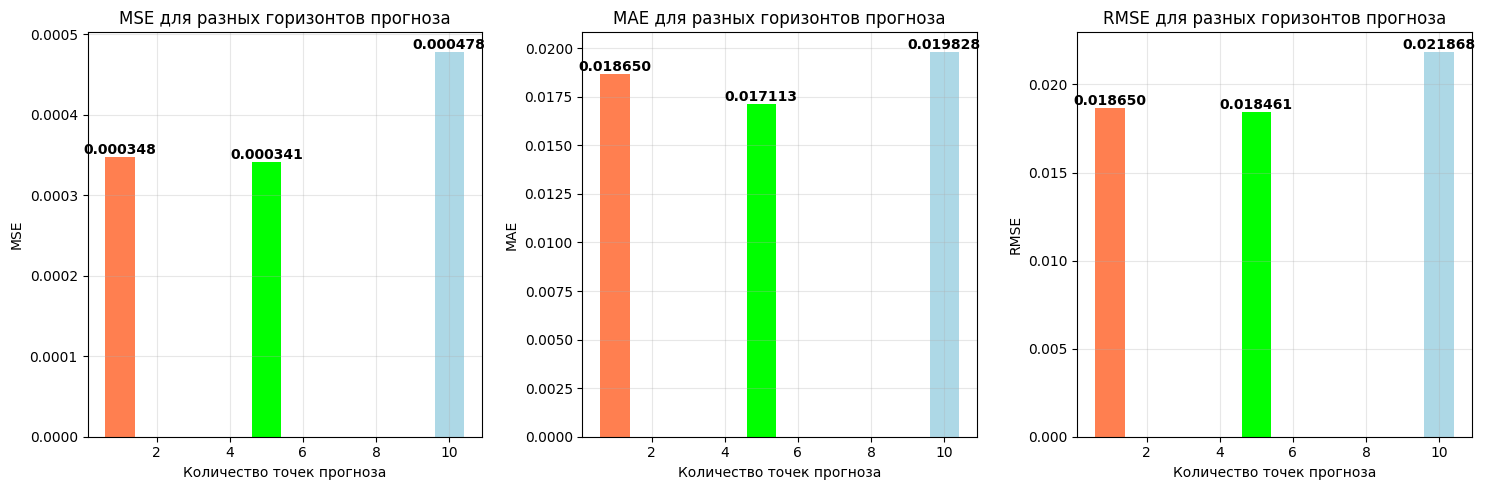

In [135]:
if all(steps in errors for steps in forecast_points):
    metrics = ['MSE', 'MAE', 'RMSE']
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    for i, metric in enumerate(metrics):
        values = [errors[steps][metric] for steps in forecast_points]
        axes[i].bar(forecast_points, values, color=['coral', 'lime', 'lightblue'])
        axes[i].set_title(f'{metric} для разных горизонтов прогноза')
        axes[i].set_xlabel('Количество точек прогноза')
        axes[i].set_ylabel(metric)
        axes[i].grid(True, alpha=0.3)

        for j, v in enumerate(values):
            axes[i].text(forecast_points[j], v, f'{v:.6f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [138]:
print(f'О модели ARIMA: \n{'='*83}')
print(best_model.summary())

О модели ARIMA: 
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:               166830
Model:                 ARIMA(3, 1, 3)   Log Likelihood               59217.516
Date:                Wed, 19 Nov 2025   AIC                        -118421.031
Time:                        16:00:19   BIC                        -118350.858
Sample:                             0   HQIC                       -118400.214
                             - 166830                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1727      0.005    -32.373      0.000      -0.183      -0.162
ar.L2          0.7002      0.006    114.180      0.000       0.688       0.712
ar.L3         -0.1068      0.002   

Ошибки в сотни тысяч раз меньше чем у предыдущих моделей. Показатели стабильны при увеличении горизонта прогноза, что говорит о хорошей устойчивости модели ARIMA. Также прогноз визуально близок к фактическим значениям, особенно для коротких горизонтов (1-5). При этом потребовал меньше ресурсов